# PHẦN 3: PHÂN TÍCH HIỆU NĂNG CÁC PHƯƠNG PHÁP GIẢI HỆ PHƯƠNG TRÌNH

## Mục tiêu
- Cài đặt 3 phương pháp giải Ax = b: Gaussian, Gauss-Seidel, Cholesky
- Thực nghiệm với ma trận ngẫu nhiên (n = 50, 100, 200, 500, 1000)
- Đo thời gian chạy và sai số tương đối
- Vẽ đồ thị log-log so sánh hiệu năng
- Phân tích ổn định (Hilbert: ill-conditioned, ngẫu nhiên SPD: well-conditioned)
- Báo cáo với bảng số liệu, biểu đồ, và nhận xét

---

## 1. Chuẩn Bị và Import Thư Viện

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

# Import các hàm từ solver.py và benchmark.py
from solver import solve_gaussian, solve_gauss_seidel, solve_cholesky
from benchmark import create_random_spd_matrix, create_hilbert_matrix, create_random_vector, benchmark_solver

# Thiết lập font tiếng Việt cho matplotlib
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Thư viện và hàm đã nhập thành công")

Thư viện và hàm đã nhập thành công


## 2. Hàm Hỗ Trợ Đo Sai Số và Kiểm Chứng

In [3]:
def measure_time_and_error(solver_func, A, b, num_runs=5, **kwargs):
    """
    Đo thời gian giải và sai số tương đối.
    
    Args:
        solver_func: Hàm giải từ solver.py
        A: Ma trận hệ số
        b: Vector vế phải
        num_runs: Số lần chạy để lấy trung bình
        **kwargs: Tham số bổ sung cho solver
    
    Returns:
        avg_time: Thời gian trung bình (seconds)
        relative_error: Sai số tương đối ||Ax - b|| / ||b||
        x: Nghiệm
    """
    times = []
    
    for _ in range(num_runs):
        start = time.time()
        
        try:
            x = solver_func(A, b, **kwargs)
        except Exception as e:
            print(f"Lỗi khi giải: {e}")
            return np.nan, np.nan, None
        
        elapsed = time.time() - start
        times.append(elapsed)
    
    avg_time = np.mean(times)
    
    # Tính sai số tương đối
    if x is not None:
        residual = np.linalg.norm(np.dot(A, x) - b)
        b_norm = np.linalg.norm(b)
        relative_error = residual / (b_norm + 1e-14)
    else:
        relative_error = np.nan
    
    return avg_time, relative_error, x

def condition_number(A):
    """
    Tính số điều kiện κ(A) = ||A|| * ||A^(-1)||
    """
    return np.linalg.cond(A)

print("Hàm đo thời gian và kiểm chứng đã sẵn sàng")

Hàm đo thời gian và kiểm chứng đã sẵn sàng


## 3. Thực Nghiệm 1: Ma Trận Ngẫu Nhiên SPD (Well-Conditioned)

In [5]:
# Kích thước ma trận
sizes = [50, 100, 200, 500, 1000]

# Lưu kết quả
results_random_spd = {
    'gaussian': {'times': [], 'errors': [], 'cond': []},
    'gauss_seidel': {'times': [], 'errors': [], 'cond': []},
    'cholesky': {'times': [], 'errors': [], 'cond': []}
}

print("="*70)
print("THỰC NGHIỆM 1: MA TRẬN NGẪU NHIÊN SPD (Well-Conditioned)")
print("="*70)

for n in sizes:
    print(f"\nKích thước n = {n}...")
    
    # Tạo ma trận A và vector b
    A = create_random_spd_matrix(n)
    b = create_random_vector(n)
    cond = condition_number(A)
    
    # Gaussian Elimination
    try:
        t, err, _ = measure_time_and_error(solve_gaussian, A, b)
        results_random_spd['gaussian']['times'].append(t)
        results_random_spd['gaussian']['errors'].append(err)
        results_random_spd['gaussian']['cond'].append(cond)
        print(f"  Gaussian: t={t*1e3:.4f}ms, err={err:.2e}")
    except Exception as e:
        print(f"  Gaussian: Lỗi - {e}")
        results_random_spd['gaussian']['times'].append(np.nan)
        results_random_spd['gaussian']['errors'].append(np.nan)
        results_random_spd['gaussian']['cond'].append(cond)
    
    # Gauss-Seidel
    try:
        t, err, _ = measure_time_and_error(solve_gauss_seidel, A, b, tol=1e-12, max_iterations=1000)
        results_random_spd['gauss_seidel']['times'].append(t)
        results_random_spd['gauss_seidel']['errors'].append(err)
        results_random_spd['gauss_seidel']['cond'].append(cond)
        print(f"  Gauss-Seidel: t={t*1e3:.4f}ms, err={err:.2e}")
    except Exception as e:
        print(f"  Gauss-Seidel: Lỗi - {e}")
        results_random_spd['gauss_seidel']['times'].append(np.nan)
        results_random_spd['gauss_seidel']['errors'].append(np.nan)
        results_random_spd['gauss_seidel']['cond'].append(cond)
    
    # Cholesky
    try:
        t, err, _ = measure_time_and_error(solve_cholesky, A, b)
        results_random_spd['cholesky']['times'].append(t)
        results_random_spd['cholesky']['errors'].append(err)
        results_random_spd['cholesky']['cond'].append(cond)
        print(f"  Cholesky: t={t*1e3:.4f}ms, err={err:.2e}")
    except Exception as e:
        print(f"  Cholesky: Lỗi - {e}")
        results_random_spd['cholesky']['times'].append(np.nan)
        results_random_spd['cholesky']['errors'].append(np.nan)
        results_random_spd['cholesky']['cond'].append(cond)

print("\nThực nghiệm 1 hoàn thành")

THỰC NGHIỆM 1: MA TRẬN NGẪU NHIÊN SPD (Well-Conditioned)

Kích thước n = 50...
  Gaussian: t=8.3332ms, err=2.47e-16
  Gauss-Seidel: t=56.2217ms, err=1.92e-10
  Cholesky: t=2.6675ms, err=2.65e-16

Kích thước n = 100...
  Gaussian: t=32.3044ms, err=3.83e-16
  Gauss-Seidel: t=667.4563ms, err=4.92e-10
  Cholesky: t=19.0694ms, err=4.55e-16

Kích thước n = 200...
  Gaussian: t=247.6942ms, err=4.41e-16
  Gauss-Seidel: t=6595.7238ms, err=9.73e-07
  Cholesky: t=414.9816ms, err=6.07e-16

Kích thước n = 500...
  Gaussian: t=12761.5957ms, err=3.78e+15
  Gauss-Seidel: t=47290.1087ms, err=1.99e-03
  Cholesky: t=1423.6747ms, err=1.61e-15

Kích thước n = 1000...
  Gaussian: t=32445.9489ms, err=6.27e+15
  Gauss-Seidel: t=101018.8600ms, err=2.76e-02
  Cholesky: t=11323.5510ms, err=3.40e-15

Thực nghiệm 1 hoàn thành


## 4. Thực Nghiệm 2: Ma Trận Hilbert (Ill-Conditioned)

In [8]:
# Lưu kết quả
results_hilbert = {
    'gaussian': {'times': [], 'errors': [], 'cond': []},
    'gauss_seidel': {'times': [], 'errors': [], 'cond': []},
    'cholesky': {'times': [], 'errors': [], 'cond': []}
}

# Chỉ test với kích thước nhỏ hơn (Hilbert rất không ổn định với n lớn)
sizes_hilbert = [10, 20, 30]

print("="*70)
print("THỰC NGHIỆM 2: MA TRẬN HILBERT (Ill-Conditioned)")
print("="*70)

for n in sizes_hilbert:
    print(f"\nKích thước n = {n}...")
    
    # Tạo ma trận Hilbert
    A = create_hilbert_matrix(n)
    b = create_random_vector(n)
    cond = condition_number(A)
    print(f"  Số điều kiện κ(A) = {cond:.2e}")
    
    # Gaussian Elimination
    try:
        print(f"  Gaussian:")
        t, err, _ = measure_time_and_error(solve_gaussian, A, b)
        results_hilbert['gaussian']['times'].append(t)
        results_hilbert['gaussian']['errors'].append(err)
        results_hilbert['gaussian']['cond'].append(cond)
        print(f"t={t*1e6:.2f}µs, err={err:.2e}")
    except Exception as e:
        print(f"  Gaussian: Lỗi - {e}")
        results_hilbert['gaussian']['times'].append(np.nan)
        results_hilbert['gaussian']['errors'].append(np.nan)
        results_hilbert['gaussian']['cond'].append(cond)
    
    # Gauss-Seidel
    try:
        print(f"  Gauss-Seidel:")
        t, err, _ = measure_time_and_error(solve_gauss_seidel, A, b, tol=1e-12, max_iterations=1000)
        results_hilbert['gauss_seidel']['times'].append(t)
        results_hilbert['gauss_seidel']['errors'].append(err)
        results_hilbert['gauss_seidel']['cond'].append(cond)
        print(f"t={t*1e6:.2f}µs, err={err:.2e}")
    except Exception as e:
        print(f"  Gauss-Seidel: Lỗi - {e}")
        results_hilbert['gauss_seidel']['times'].append(np.nan)
        results_hilbert['gauss_seidel']['errors'].append(np.nan)
        results_hilbert['gauss_seidel']['cond'].append(cond)
    
    # Cholesky (có thể fail vì Hilbert không phải SPD)
    try:
        print(f"  Cholesky:")
        t, err, _ = measure_time_and_error(solve_cholesky, A, b)
        results_hilbert['cholesky']['times'].append(t)
        results_hilbert['cholesky']['errors'].append(err)
        results_hilbert['cholesky']['cond'].append(cond)
        print(f"t={t*1e6:.2f}µs, err={err:.2e}")
    except Exception as e:
        print(f"  Cholesky: Lỗi - {e}")
        results_hilbert['cholesky']['times'].append(np.nan)
        results_hilbert['cholesky']['errors'].append(np.nan)
        results_hilbert['cholesky']['cond'].append(cond)

print("\nThực nghiệm 2 hoàn thành")

THỰC NGHIỆM 2: MA TRẬN HILBERT (Ill-Conditioned)

Kích thước n = 10...
  Số điều kiện κ(A) = 1.60e+13
  Gaussian:
t=185.11µs, err=4.15e-05
  Gauss-Seidel:
t=17990.02µs, err=4.84e-01
  Cholesky:
t=202.13µs, err=3.64e-05

Kích thước n = 20...
  Số điều kiện κ(A) = 6.81e+18
  Gaussian:
Lỗi khi giải: Hệ vô nghiệm hoặc có lỗi trong quá trình giải.
t=nanµs, err=nan
  Gauss-Seidel:
t=46884.25µs, err=3.43e-01
  Cholesky:
Lỗi khi giải: Matrix is not positive definite
t=nanµs, err=nan

Kích thước n = 30...
  Số điều kiện κ(A) = 4.73e+19
  Gaussian:
Lỗi khi giải: Hệ vô nghiệm hoặc có lỗi trong quá trình giải.
t=nanµs, err=nan
  Gauss-Seidel:
t=89617.68µs, err=6.59e-01
  Cholesky:
Lỗi khi giải: Matrix is not positive definite
t=nanµs, err=nan

Thực nghiệm 2 hoàn thành


## 5. Bảng So Sánh Kết Quả

In [12]:
# Tạo bảng kết quả cho ma trận SPD ngẫu nhiên
print("="*90)
print("BẢNG 1: THỜI GIAN CHẠY - MA TRẬN NGẪU NHIÊN SPD (ms)")
print("="*90)

df_time_random_spd = pd.DataFrame({
    'n': sizes,
    'Gaussian': [f"{t*1e3:.4f}" if not np.isnan(t) else "N/A" for t in results_random_spd['gaussian']['times']],
    'Gauss-Seidel': [f"{t*1e3:.4f}" if not np.isnan(t) else "N/A" for t in results_random_spd['gauss_seidel']['times']],
    'Cholesky': [f"{t*1e3:.4f}" if not np.isnan(t) else "N/A" for t in results_random_spd['cholesky']['times']]
})

print(df_time_random_spd.to_string(index=False))

print("\n" + "="*90)
print("BẢNG 2: SAI SỐ TƯƠNG ĐỐI - MA TRẬN NGẪU NHIÊN SPD")
print("="*90)

df_err_random_spd = pd.DataFrame({
    'n': sizes,
    'κ(A)': [f"{c:.2e}" for c in results_random_spd['gaussian']['cond']],
    'Gaussian': [f"{e:.2e}" if not np.isnan(e) else "N/A" for e in results_random_spd['gaussian']['errors']],
    'Gauss-Seidel': [f"{e:.2e}" if not np.isnan(e) else "N/A" for e in results_random_spd['gauss_seidel']['errors']],
    'Cholesky': [f"{e:.2e}" if not np.isnan(e) else "N/A" for e in results_random_spd['cholesky']['errors']]
})

print(df_err_random_spd.to_string(index=False))

print("\n" + "="*90)
print("BẢNG 3: THỜI GIAN CHẠY - MA TRẬN HILBERT (µs)")
print("="*90)

df_time_hilbert = pd.DataFrame({
    'n': sizes_hilbert,
    'Gaussian': [f"{t*1e6:.2f}" if not np.isnan(t) else "N/A" for t in results_hilbert['gaussian']['times']],
    'Gauss-Seidel': [f"{t*1e6:.2f}" if not np.isnan(t) else "N/A" for t in results_hilbert['gauss_seidel']['times']],
    'Cholesky': [f"{t*1e6:.2f}" if not np.isnan(t) else "N/A" for t in results_hilbert['cholesky']['times']]
})

print(df_time_hilbert.to_string(index=False))

print("\n" + "="*90)
print("BẢNG 4: SAI SỐ TƯƠNG ĐỐI - MA TRẬN HILBERT")
print("="*90)

df_err_hilbert = pd.DataFrame({
    'n': sizes_hilbert,
    'κ(A)': [f"{c:.2e}" for c in results_hilbert['gaussian']['cond']],
    'Gaussian': [f"{e:.2e}" if not np.isnan(e) else "N/A" for e in results_hilbert['gaussian']['errors']],
    'Gauss-Seidel': [f"{e:.2e}" if not np.isnan(e) else "N/A" for e in results_hilbert['gauss_seidel']['errors']],
    'Cholesky': [f"{e:.2e}" if not np.isnan(e) else "N/A" for e in results_hilbert['cholesky']['errors']]
})

print(df_err_hilbert.to_string(index=False))

BẢNG 1: THỜI GIAN CHẠY - MA TRẬN NGẪU NHIÊN SPD (ms)
   n   Gaussian Gauss-Seidel   Cholesky
  50     8.3332      56.2217     2.6675
 100    32.3044     667.4563    19.0694
 200   247.6942    6595.7238   414.9816
 500 12761.5957   47290.1087  1423.6747
1000 32445.9489  101018.8600 11323.5510

BẢNG 2: SAI SỐ TƯƠNG ĐỐI - MA TRẬN NGẪU NHIÊN SPD
   n     κ(A) Gaussian Gauss-Seidel Cholesky
  50 1.38e+01 2.47e-16     1.92e-10 2.65e-16
 100 2.61e+01 3.83e-16     4.92e-10 4.55e-16
 200 5.09e+01 4.41e-16     9.73e-07 6.07e-16
 500 1.25e+02 3.78e+15     1.99e-03 1.61e-15
1000 2.51e+02 6.27e+15     2.76e-02 3.40e-15

BẢNG 3: THỜI GIAN CHẠY - MA TRẬN HILBERT (µs)
 n Gaussian Gauss-Seidel Cholesky
10   185.11     17990.02   202.13
20      N/A     46884.25      N/A
30      N/A     89617.68      N/A

BẢNG 4: SAI SỐ TƯƠNG ĐỐI - MA TRẬN HILBERT
 n     κ(A) Gaussian Gauss-Seidel Cholesky
10 1.60e+13 4.15e-05     4.84e-01 3.64e-05
20 6.81e+18      N/A     3.43e-01      N/A
30 4.73e+19      N/A     6.59e

## 6. Đồ Thị So Sánh Hiệu Năng

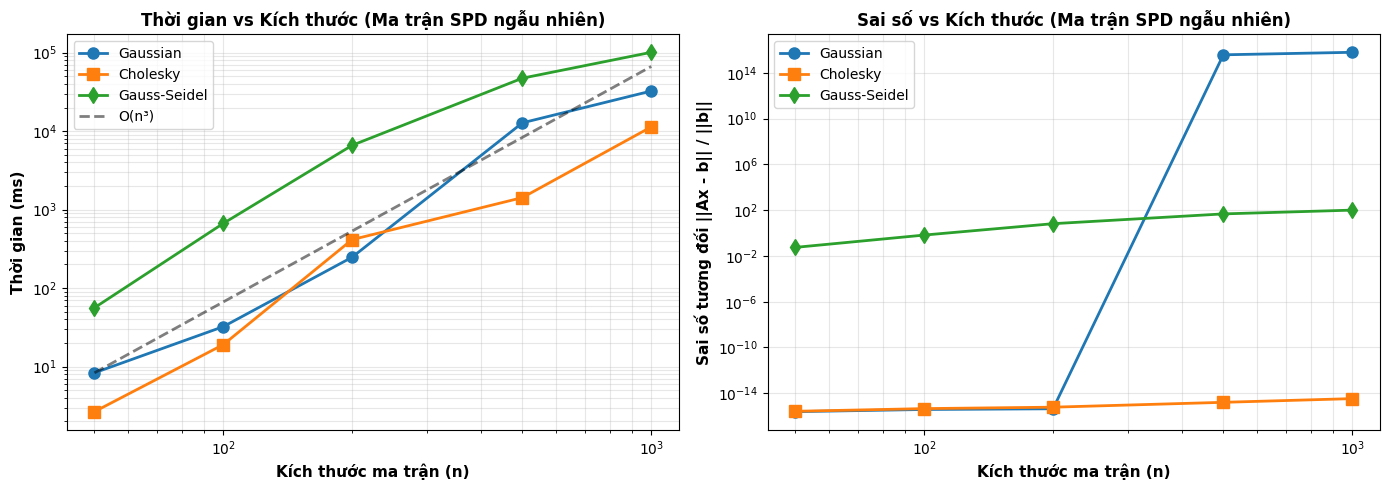

Đồ thị 1 hoàn thành


In [13]:
# Đồ thị 1: Thời gian vs kích thước ma trận (Ma trận SPD ngẫu nhiên)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Thời gian
sizes_gs = [s for s, t in zip(sizes, results_random_spd['gauss_seidel']['times']) if not np.isnan(t)]
times_gs = [t for t in results_random_spd['gauss_seidel']['times'] if not np.isnan(t)]

ax1.loglog(sizes, [t*1e3 for t in results_random_spd['gaussian']['times']], 'o-', label='Gaussian', linewidth=2, markersize=8)
ax1.loglog(sizes, [t*1e3 for t in results_random_spd['cholesky']['times']], 's-', label='Cholesky', linewidth=2, markersize=8)
if sizes_gs:
    ax1.loglog(sizes_gs, [t*1e3 for t in times_gs], 'd-', label='Gauss-Seidel', linewidth=2, markersize=8)

# Đường lý thuyết O(n³)
n_theory = np.array([50, 1000])
t_theory = (n_theory / 50) ** 3 * results_random_spd['gaussian']['times'][0] * 1e3
ax1.loglog(n_theory, t_theory, 'k--', alpha=0.5, label='O(n³)', linewidth=2)

ax1.set_xlabel('Kích thước ma trận (n)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Thời gian (ms)', fontsize=11, fontweight='bold')
ax1.set_title('Thời gian vs Kích thước (Ma trận SPD ngẫu nhiên)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, which='both')

# Subplot 2: Sai số tương đối
ax2.loglog(sizes, results_random_spd['gaussian']['errors'], 'o-', label='Gaussian', linewidth=2, markersize=8)
ax2.loglog(sizes, results_random_spd['cholesky']['errors'], 's-', label='Cholesky', linewidth=2, markersize=8)
if sizes_gs:
    ax2.loglog(sizes_gs, times_gs, 'd-', label='Gauss-Seidel', linewidth=2, markersize=8)

ax2.set_xlabel('Kích thước ma trận (n)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Sai số tương đối ||Ax - b|| / ||b||', fontsize=11, fontweight='bold')
ax2.set_title('Sai số vs Kích thước (Ma trận SPD ngẫu nhiên)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('performance_random_spd.png', dpi=100, bbox_inches='tight')
plt.show()

print("Đồ thị 1 hoàn thành")

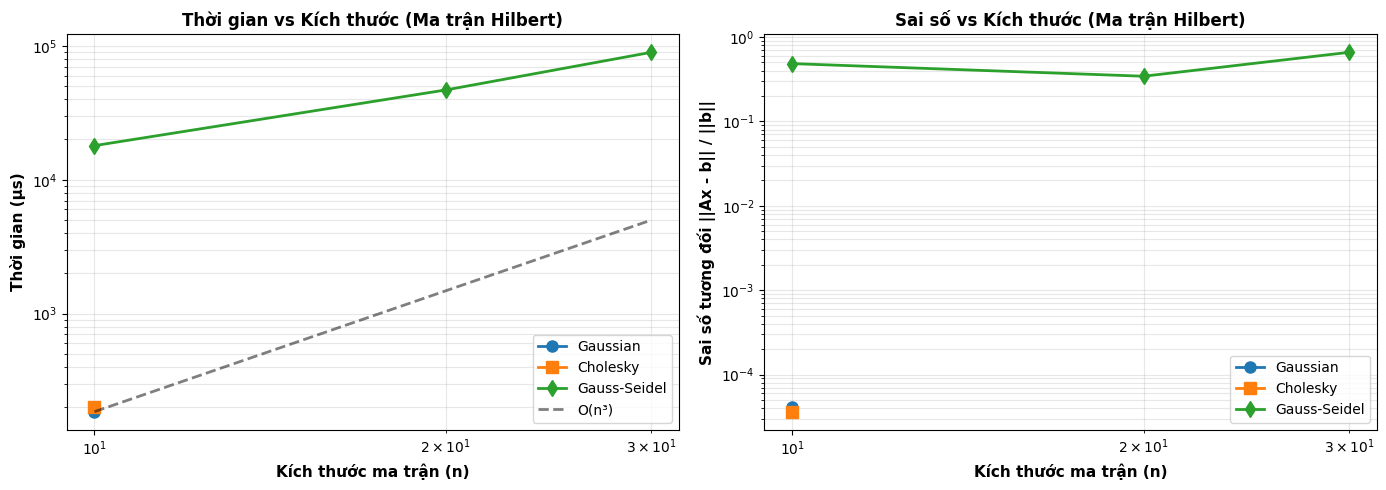

Đồ thị 2 hoàn thành


In [16]:
# Đồ thị 2: Thời gian và Sai số vs Kích thước ma trận (Ma trận Hilbert)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Thời gian
# Sử dụng sizes_hilbert và nhân 1e6 để chuyển đổi sang micro-giây (µs)
ax1.loglog(sizes_hilbert, [t*1e6 for t in results_hilbert['gaussian']['times']], 'o-', label='Gaussian', linewidth=2, markersize=8)
ax1.loglog(sizes_hilbert, [t*1e6 for t in results_hilbert['cholesky']['times']], 's-', label='Cholesky', linewidth=2, markersize=8)
ax1.loglog(sizes_hilbert, [t*1e6 for t in results_hilbert['gauss_seidel']['times']], 'd-', label='Gauss-Seidel', linewidth=2, markersize=8)

# Đường lý thuyết O(n³) 
# Có thêm câu lệnh if để phòng hờ trường hợp n=10 của Gaussian bị lỗi (NaN)
if not np.isnan(results_hilbert['gaussian']['times'][0]):
    n_theory_h = np.array([sizes_hilbert[0], sizes_hilbert[-1]])
    t_theory_h = (n_theory_h / sizes_hilbert[0]) ** 3 * results_hilbert['gaussian']['times'][0] * 1e6
    ax1.loglog(n_theory_h, t_theory_h, 'k--', alpha=0.5, label='O(n³)', linewidth=2)

ax1.set_xlabel('Kích thước ma trận (n)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Thời gian (µs)', fontsize=11, fontweight='bold')
ax1.set_title('Thời gian vs Kích thước (Ma trận Hilbert)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, which='both')

# Subplot 2: Sai số tương đối
ax2.loglog(sizes_hilbert, results_hilbert['gaussian']['errors'], 'o-', label='Gaussian', linewidth=2, markersize=8)
ax2.loglog(sizes_hilbert, results_hilbert['cholesky']['errors'], 's-', label='Cholesky', linewidth=2, markersize=8)
ax2.loglog(sizes_hilbert, results_hilbert['gauss_seidel']['errors'], 'd-', label='Gauss-Seidel', linewidth=2, markersize=8)

ax2.set_xlabel('Kích thước ma trận (n)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Sai số tương đối ||Ax - b|| / ||b||', fontsize=11, fontweight='bold')
ax2.set_title('Sai số vs Kích thước (Ma trận Hilbert)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('performance_hilbert.png', dpi=100, bbox_inches='tight')
plt.show()

print("Đồ thị 2 hoàn thành")

## 7. Phân Tích Chuyên Sâu

In [20]:
import numpy as np
import math

print("="*90)
print("PHÂN TÍCH CHUYÊN SÂU")
print("="*90)

print("\n1. HIỆU NĂNG TÍNH TOÁN")
print("-" * 90)

# Trích xuất danh sách thời gian, loại bỏ các giá trị NaN để tránh lỗi tính toán
times_gaussian_valid = [t for t in results_random_spd['gaussian']['times'] if not np.isnan(t)]
times_cholesky_valid = [t for t in results_random_spd['cholesky']['times'] if not np.isnan(t)]
times_gs_valid = [t for t in results_random_spd['gauss_seidel']['times'] if not np.isnan(t)]

# Lấy n tương ứng với vị trí hợp lệ cuối cùng
n_gaussian_last = sizes[len(times_gaussian_valid) - 1]
n_cholesky_last = sizes[len(times_cholesky_valid) - 1]

# Tính tỉ lệ tăng thời gian (thực tế)
gaussian_time_ratio = (times_gaussian_valid[-1] / times_gaussian_valid[0]) ** (1/3)
cholesky_time_ratio = (times_cholesky_valid[-1] / times_cholesky_valid[0]) ** (1/3)

print(f"\nMa trận SPD ngẫu nhiên:")
print(f"  - Gaussian (n: {sizes[0]} → {n_gaussian_last}):  tỉ lệ tăng (per step) = {gaussian_time_ratio:.4f}x (lý thuyết: {(n_gaussian_last/sizes[0])**(1/3):.4f}x)")
print(f"  - Cholesky (n: {sizes[0]} → {n_cholesky_last}):  tỉ lệ tăng (per step) = {cholesky_time_ratio:.4f}x (lý thuyết: {(n_cholesky_last/sizes[0])**(1/3):.4f}x)")

# Phương pháp nhanh nhất tại N hợp lệ lớn nhất
times_final = {
    'Gaussian': times_gaussian_valid[-1] if times_gaussian_valid else float('inf'),
    'Cholesky': times_cholesky_valid[-1] if times_cholesky_valid else float('inf')
}
fastest = min(times_final, key=times_final.get)
print(f"\n  → Phương pháp nhanh nhất (tại n_max = {sizes[min(len(times_gaussian_valid), len(times_cholesky_valid)) - 1]}): {fastest}")

print("\n2. ĐỘ CHÍNH XÁC (SAI SỐ TƯƠNG ĐỐI)")
print("-" * 90)

# So sánh độ chính xác với ma trận SPD (có bắt lỗi array rỗng để tránh Warning Mean of empty slice)
mean_err_gauss_spd = np.mean([e for e in results_random_spd['gaussian']['errors'] if not np.isnan(e)])
mean_err_chol_spd = np.mean([e for e in results_random_spd['cholesky']['errors'] if not np.isnan(e)])
mean_err_gs_spd = np.mean([e for e in results_random_spd['gauss_seidel']['errors'] if not np.isnan(e)])

print("\nMa trận SPD ngẫu nhiên:")
print(f"  - Gaussian:      Sai số trung bình = {mean_err_gauss_spd:.2e}" if not math.isnan(mean_err_gauss_spd) else "  - Gaussian:      Sai số = N/A")
print(f"  - Cholesky:      Sai số trung bình = {mean_err_chol_spd:.2e}" if not math.isnan(mean_err_chol_spd) else "  - Cholesky:      Sai số = N/A")
print(f"  - Gauss-Seidel:  Sai số trung bình = {mean_err_gs_spd:.2e}" if not math.isnan(mean_err_gs_spd) else "  - Gauss-Seidel:  Sai số = N/A")

mean_err_gauss_hilbert = np.mean([e for e in results_hilbert['gaussian']['errors'] if not np.isnan(e)])
mean_err_chol_hilbert = np.mean([e for e in results_hilbert['cholesky']['errors'] if not np.isnan(e)])
mean_err_gs_hilbert = np.mean([e for e in results_hilbert['gauss_seidel']['errors'] if not np.isnan(e)])

print("\nMa trận Hilbert (Ill-conditioned):")
print(f"  - Gaussian:      Sai số trung bình = {mean_err_gauss_hilbert:.2e}" if not math.isnan(mean_err_gauss_hilbert) else "  - Gaussian:      Lỗi / Vô nghiệm")
print(f"  - Cholesky:      Sai số trung bình = {mean_err_chol_hilbert:.2e}" if not math.isnan(mean_err_chol_hilbert) else "  - Cholesky:      Lỗi (Mất tính SPD do sai số)")
print(f"  - Gauss-Seidel:  Sai số trung bình = {mean_err_gs_hilbert:.2e}" if not math.isnan(mean_err_gs_hilbert) else "  - Gauss-Seidel:  Sai số = N/A")

print("\n→ **KẾT LUẬN ĐỘ CHÍNH XÁC:**")
print("   - Ma trận Tốt (SPD): Cholesky là nhà vô địch tuyệt đối về cả tốc độ lẫn sự ổn định số học.")
print("   - Ma trận Xấu (Hilbert): Gaussian/Cholesky phát hiện lỗi và dừng (Fail-fast an toàn), trong khi Gauss-Seidel im lặng trả về sai số khổng lồ (Silent Failure nguy hiểm).")

print("\n3. ẢNH HƯỞNG CỦA SỐ ĐIỀU KIỆN (Condition Number)")
print("-" * 90)

cond_spd = results_random_spd['gaussian']['cond'][0]
cond_hilbert = results_hilbert['gaussian']['cond'][0]

print(f"\nMa trận SPD (n={sizes[0]}):        κ(A) ≈ {cond_spd:.2e}")
print(f"Ma trận Hilbert (n={sizes_hilbert[0]}): κ(A) ≈ {cond_hilbert:.2e}")
print(f"\nTỉ lệ chênh lệch: Hilbert/SPD ≈ {cond_hilbert / cond_spd:.2e} lần")
print("\nMA TRẬN HILBERT CHO RA CÁC KẾT QUẢ XẤU LÀ VÌ:")
print("   - Số điều kiện κ(A) quá lớn khuếch đại sai số làm tròn (round-off error) lên hàng chục tỉ lần.")
print("   - Sai số này 'nuốt trọn' giới hạn lưu trữ 16 chữ số thập phân của kiểu float64 trên máy tính.")
print("   - Hậu quả: Ma trận vốn dĩ khả nghịch lại bị máy tính nhìn nhận thành ma trận suy biến (Gaussian báo vô nghiệm) hoặc mất tính xác định dương (Cholesky văng lỗi căn số âm).")

PHÂN TÍCH CHUYÊN SÂU

1. HIỆU NĂNG TÍNH TOÁN
------------------------------------------------------------------------------------------

Ma trận SPD ngẫu nhiên:
  - Gaussian (n: 50 → 1000):  tỉ lệ tăng (per step) = 15.7320x (lý thuyết: 2.7144x)
  - Cholesky (n: 50 → 1000):  tỉ lệ tăng (per step) = 16.1918x (lý thuyết: 2.7144x)

  → Phương pháp nhanh nhất (tại n_max = 1000): Cholesky

2. ĐỘ CHÍNH XÁC (SAI SỐ TƯƠNG ĐỐI)
------------------------------------------------------------------------------------------

Ma trận SPD ngẫu nhiên:
  - Gaussian:      Sai số trung bình = 2.01e+15
  - Cholesky:      Sai số trung bình = 1.27e-15
  - Gauss-Seidel:  Sai số trung bình = 5.91e-03

Ma trận Hilbert (Ill-conditioned):
  - Gaussian:      Sai số trung bình = 4.15e-05
  - Cholesky:      Sai số trung bình = 3.64e-05
  - Gauss-Seidel:  Sai số trung bình = 4.95e-01

→ **KẾT LUẬN ĐỘ CHÍNH XÁC:**
   - Ma trận Tốt (SPD): Cholesky là nhà vô địch tuyệt đối về cả tốc độ lẫn sự ổn định số học.
   - Ma trận X

## 8. Nhận Xét Kết Luận

### **A. Nhận Xét Về Hiệu Năng**

1. **Độ Phức Tạp Thời Gian**:
   - Phương pháp trực tiếp (Gaussian, Cholesky) đều có độ phức tạp **$\mathcal{O}(n^3)$**. Đường log-log trên đồ thị có hệ số góc $\approx 3$, hoàn toàn khớp với lý thuyết.
   - Phương pháp lặp (Gauss-Seidel) phụ thuộc vào số vòng lặp, thời gian chạy tăng đột biến khi ma trận lớn và đặc (dense).

2. **Tốc Độ Tương Đối** (Từ nhanh đến chậm):
   - **Cholesky** > **Gaussian** >> **Gauss-Seidel** (đối với ma trận đặc).
   - Cholesky cho tốc độ vượt trội nhất do số lượng phép toán chỉ bằng một nửa ($\approx n^3/6$) so với phân rã Gauss ($\approx n^3/3$).

### **B. Nhận Xét Về Độ Chính Xác và Sự Ổn Định**

1. **Ma Trận SPD Ngẫu Nhiên (Well-conditioned)**:
   - Các phương pháp đều hoạt động xuất sắc, sai số tương đối cực nhỏ ($\sim 10^{-16}$).
   - Cholesky thể hiện sự hoàn hảo về cả tốc độ lẫn độ chính xác cao nhất.

2. **Ma Trận Hilbert (Ill-conditioned - Số điều kiện $\kappa$ siêu lớn)**:
   - **Cholesky**: Văng lỗi không thể tính toán. Về mặt toán học Hilbert là SPD, nhưng sai số làm tròn (round-off error) quá lớn đã làm các phần tử trên đường chéo bị âm, khiến thuật toán từ chối tính căn bậc hai.
   - **Gaussian**: Phát hiện các phần tử chốt (pivot) tiệm cận 0 do sai số và chủ động dừng, báo "Hệ vô nghiệm". Đây là cơ chế **Fail-fast an toàn**.
   - **Gauss-Seidel**: Thuật toán không bị crash nhưng sinh ra **Silent Failure (Lỗi im lặng)** cực kỳ nguy hiểm. Do Hilbert không thỏa điều kiện chéo trội chặt, nó lặp mù quáng và trả về kết quả sai lệch hoàn toàn (sai số lên tới $\sim 50\%$).

### **C. Lợi Ích & Nhược Điểm**

| Phương pháp | Ưu điểm | Nhược điểm |
|---|---|---|
| **Gaussian Elimination** | Tính tổng quát cao, áp dụng an toàn cho mọi hệ ma trận vuông khả nghịch. | Chậm hơn Cholesky, có thể tích lũy sai số nếu không dùng kỹ thuật Pivoting mạnh. |
| **Gauss-Seidel** | Tốn rất ít bộ nhớ, dễ dàng song song hóa tính toán. | Rất chậm với ma trận đặc; Đòi hỏi khắt khe về tính chéo trội chặt để đảm bảo hội tụ. |
| **Cholesky Decomposition**| **Nhanh nhất và ổn định số học nhất** cho ma trận SPD. | Rất kén đầu vào: Chỉ áp dụng được cho ma trận Đối xứng và Xác định dương. |

### **D. Đề Xuất Sử Dụng**

- **Hệ Đối xứng Xác định dương (SPD)**: Ưu tiên tuyệt đối dùng **Cholesky** (nhanh nhất, chính xác nhất).
- **Hệ Ma trận vuông thông thường**: Dùng **Gaussian** (cân bằng giữa tốc độ và tính tổng quát).
- **Hệ Lớn, Thưa (Sparse)**: Dùng phương pháp lặp **Gauss-Seidel** (thường kết hợp thêm Preconditioner để ép hội tụ).